In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 🧪 Part 1 — Data Loading & Inspection

In [105]:
# Import the dataset into a pandas DataFrame.
df = pd.read_csv('global_air_pollution_data.csv')
df.info()

# total number of rows
len(df)

# Number of columns
df.columns.size

df.shape # returns a tuple (row, column)

# List all column names and their data types.
df.dtypes

# Identify columns with missing values.
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   country_name        23036 non-null  object
 1   city_name           23462 non-null  object
 2   aqi_value           23463 non-null  int64 
 3   aqi_category        23463 non-null  object
 4   co_aqi_value	       23463 non-null  int64 
 5   co_aqi_category     23463 non-null  object
 6   ozone_aqi_value     23463 non-null  int64 
 7   ozone_aqi_category  23463 non-null  object
 8   no2_aqi_value       23463 non-null  int64 
 9   no2_aqi_category    23463 non-null  object
 10  pm2.5_aqi_value     23463 non-null  int64 
 11  pm2.5_aqi_category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


country_name          427
city_name               1
aqi_value               0
aqi_category            0
co_aqi_value\t          0
co_aqi_category         0
ozone_aqi_value         0
ozone_aqi_category      0
no2_aqi_value           0
no2_aqi_category        0
pm2.5_aqi_value         0
pm2.5_aqi_category      0
dtype: int64

# 🧹 Part 2 — Data Cleaning

## Q6: Check whether there are duplicate rows in the dataset.

In [106]:
# Duplicates
df.duplicated().any()

#or
df.duplicated().sum()

np.int64(0)

## Q7: Determine how many unique countries exist in the dataset.

In [107]:
# Unique countries
len(df['country_name'].unique())

# Or
df['country_name'].unique().size

176

## Q8: Determine how many unique cities exist in the dataset.

In [108]:
# Unique cities
df['city_name'].unique().size

23463

## Q9: Check whether any pollution AQI values are negative or unrealistic.

In [109]:
# Unrealistic values are those over 500 
(df['aqi_value'] < 0) .any()
(df['aqi_value'] > 500) .any()

((df[['aqi_value', 'ozone_aqi_value', 'pm2.5_aqi_value']] < 0) | (df[['aqi_value', 'ozone_aqi_value', 'pm2.5_aqi_value']] > 500)) .any() # returns false meaning aqi values are realistic and none is negative


aqi_value          False
ozone_aqi_value    False
pm2.5_aqi_value    False
dtype: bool

# 📊 Part 3 — Exploratory Data Analysis

## Q10: Calculate the average AQI value for each country.

In [110]:
# Avg aqi value per country
avg_aqi_per_country = df.groupby('country_name')['aqi_value'].mean().reset_index(name = 'avg_aqi_value').round(4).sort_values(by = 'avg_aqi_value', ascending = False)
avg_aqi_per_country

,country_name,avg_aqi_value
126,Republic of Korea,421.0000
11,Bahrain,188.0000
98,Mauritania,179.0000
116,Pakistan,178.7883
163,United Arab Emirates,163.6667
...,...,...
19,Bolivia (Plurinational State of),23.7879
68,Iceland,23.0000
95,Maldives,19.0000
142,Solomon Islands,18.0000


## Q11: Identify the top 10 cities with the highest AQI values.

In [111]:
# top 10 cities aqi levels
top_cities_aqi_value = df[['city_name', 'aqi_value']].sort_values(by = 'aqi_value', ascending = False).head(10)
top_cities_aqi_value

,city_name,aqi_value
2773,Bisalpur,500
4749,Ujhani,500
2502,Jodhpur,500
2473,Kanina,500
5139,Delhi,500
5156,Durango,500
5266,Nohar,500
5475,Chhachhrauli,500
5571,Sisauli,500
2297,Phalodi,500


## Q12: Determine which country has the highest average AQI value.

In [112]:
# Country with highest avg aqi value
country_highest_avg_aqi_value = df. groupby('country_name')['aqi_value'].mean().reset_index(name = 'avg_aqi_value').sort_values(by = 'avg_aqi_value', ascending = False).head(1)
country_highest_avg_aqi_value

# Alternative 2
country_highest_avg_aqi_value_1 = df. groupby('country_name')['aqi_value'].mean().reset_index(name = 'avg_aqi_value')
country_highest_avg_aqi_value_1 = country_highest_avg_aqi_value_1.loc[country_highest_avg_aqi_value_1['avg_aqi_value'].idxmax()]
country_highest_avg_aqi_value_1

country_name     Republic of Korea
avg_aqi_value                421.0
Name: 126, dtype: object

# 📈 Part 4 — Visualization

## Q15: Bar chart showing Top 10 most polluted cities (based on AQI value)

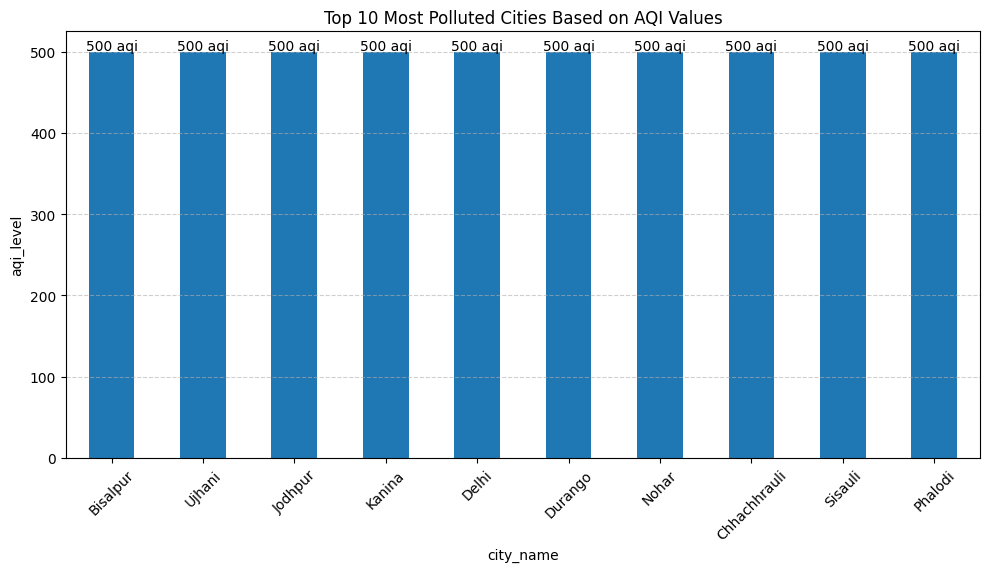

In [113]:
top_cities_aqi_value.plot(kind = 'bar', x = 'city_name', y = 'aqi_value', figsize = (10,6), legend = False)
plt.title('Top 10 Most Polluted Cities Based on AQI Values')
plt.ylabel('aqi_level')
plt.tight_layout()
plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)
plt.xticks(rotation = 45)

for city, val in enumerate(top_cities_aqi_value['aqi_value']):
    plt.text(city, val + 2, f'{val} aqi', ha = 'center')

plt.savefig('images/top_polluted_cities.png')
plt.show()

## Q16: Bar chart showing Average AQI by country

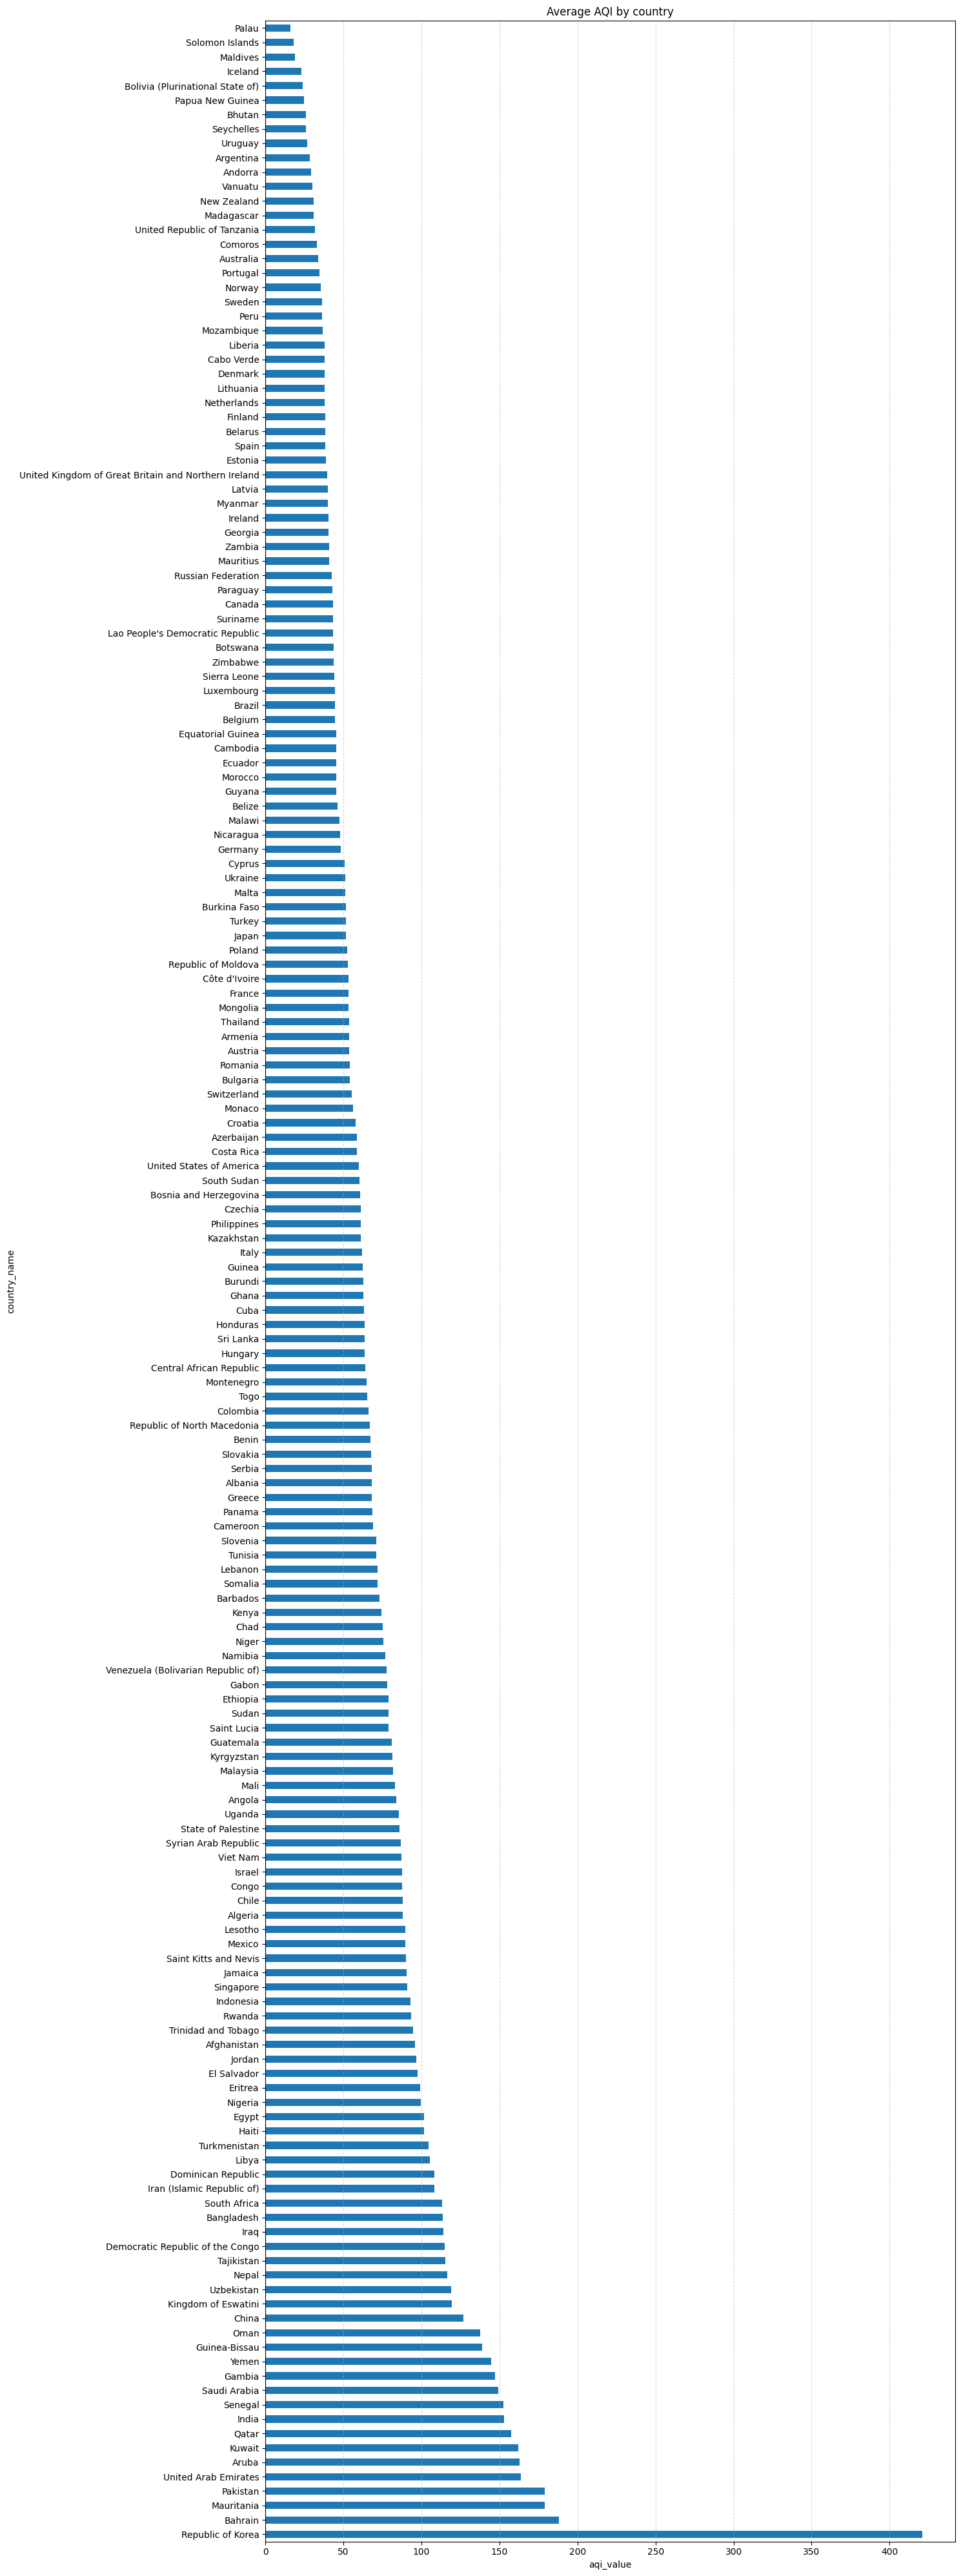

In [114]:
avg_aqi_per_country = df.groupby('country_name')['aqi_value'].mean().reset_index(name = 'avg_aqi_value').round(4).sort_values(by = 'avg_aqi_value', ascending = False)
avg_aqi_per_country

# Plotting
avg_aqi_per_country.plot(kind = 'barh', figsize = (15,40), x = 'country_name', y = 'avg_aqi_value', legend = False)
plt.title('Average AQI by country')
plt.xlabel('aqi_value')
plt.tight_layout()
plt.grid(axis = 'x', linestyle = '--', alpha = 0.5)
plt.savefig('images/average_aqi_by_country.png')
plt.show()

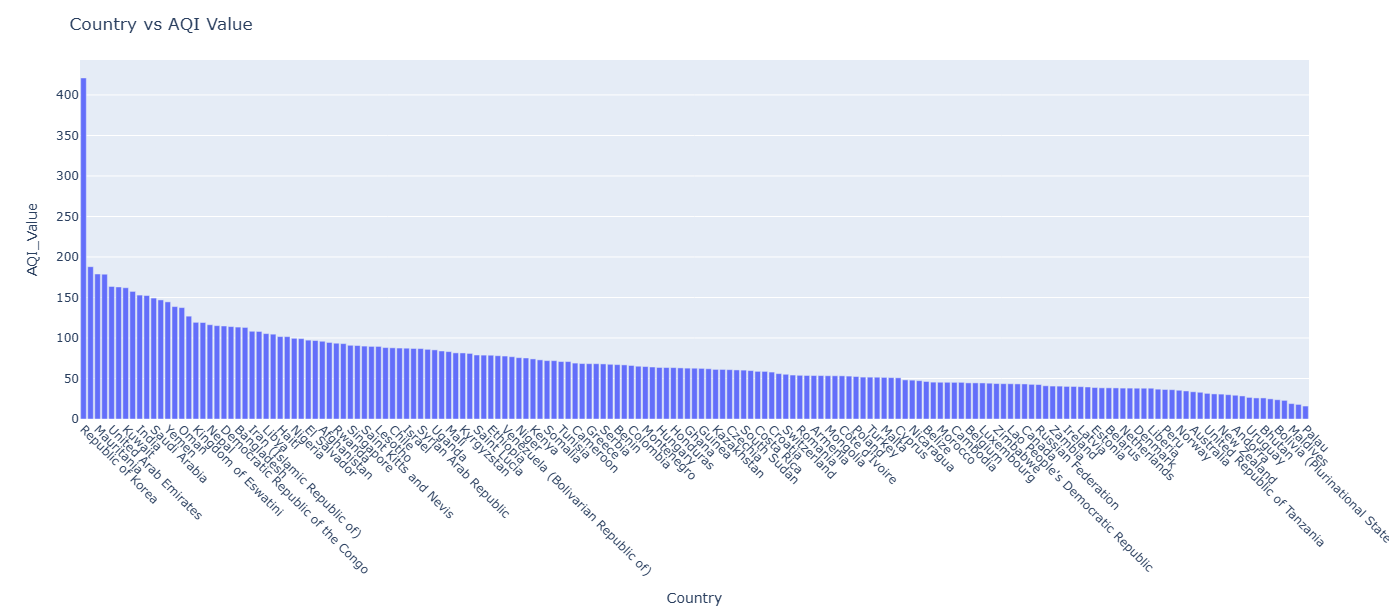

In [115]:
# Average AQI by country using plotly
fig = px.bar(
    avg_aqi_per_country,
    x = 'country_name',
    y = 'avg_aqi_value',
    labels = {'country_name': 'Country', 'avg_aqi_value': 'AQI_Value'},
    hover_data =  {'country_name': True, 'avg_aqi_value': True} # Both coutry and aqi will show on hover
)

fig.update_layout(
    height =  600,
    width =  4000,
    title = 'Country vs AQI Value',
    xaxis_tickangle = 45
)

fig.show()

## Q17: Scatter plot showing the relationship between:
### CO AQI vs NO2 AQI

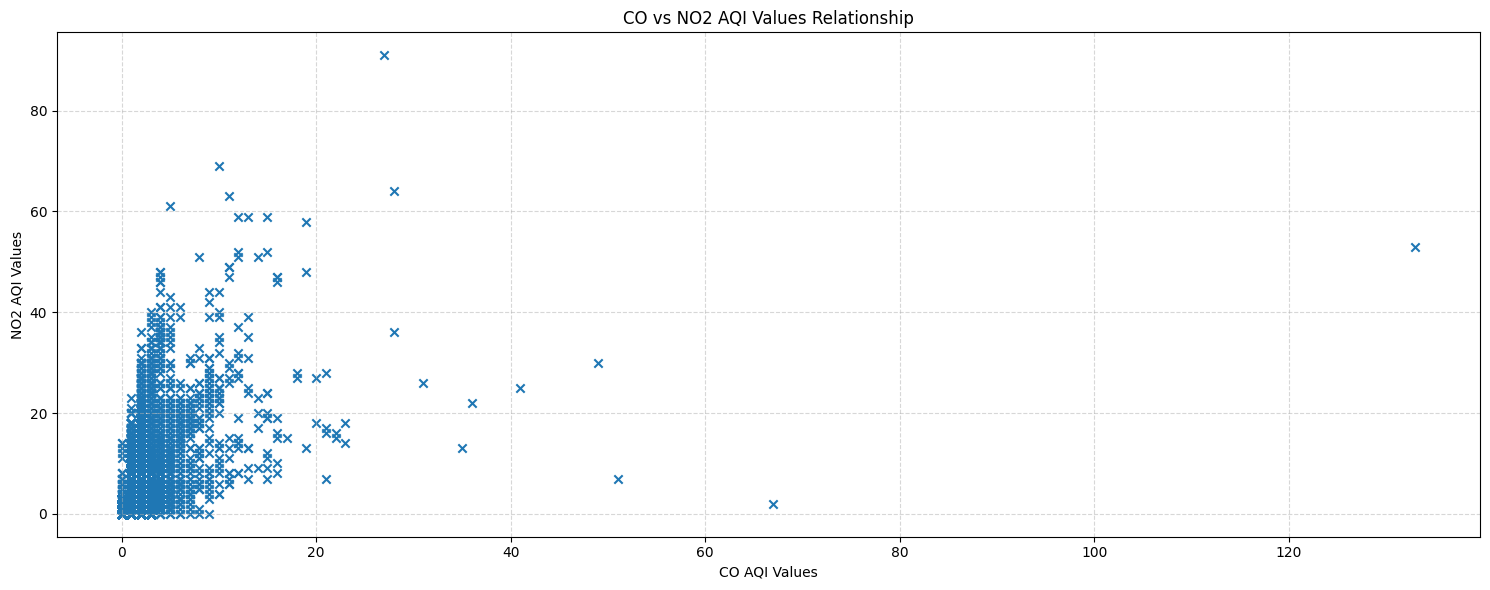

In [116]:
# Using Matplotlib
plt.figure(figsize = (15,6))
plt.scatter(x = df['co_aqi_value\t'], y = df['no2_aqi_value'], marker = 'x')
plt.title('CO vs NO2 AQI Values Relationship')
plt.xlabel('CO AQI Values')
plt.ylabel('NO2 AQI Values')
plt.tight_layout()
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.savefig('images/co_vs_no2_aqi_relationship')
plt.show()

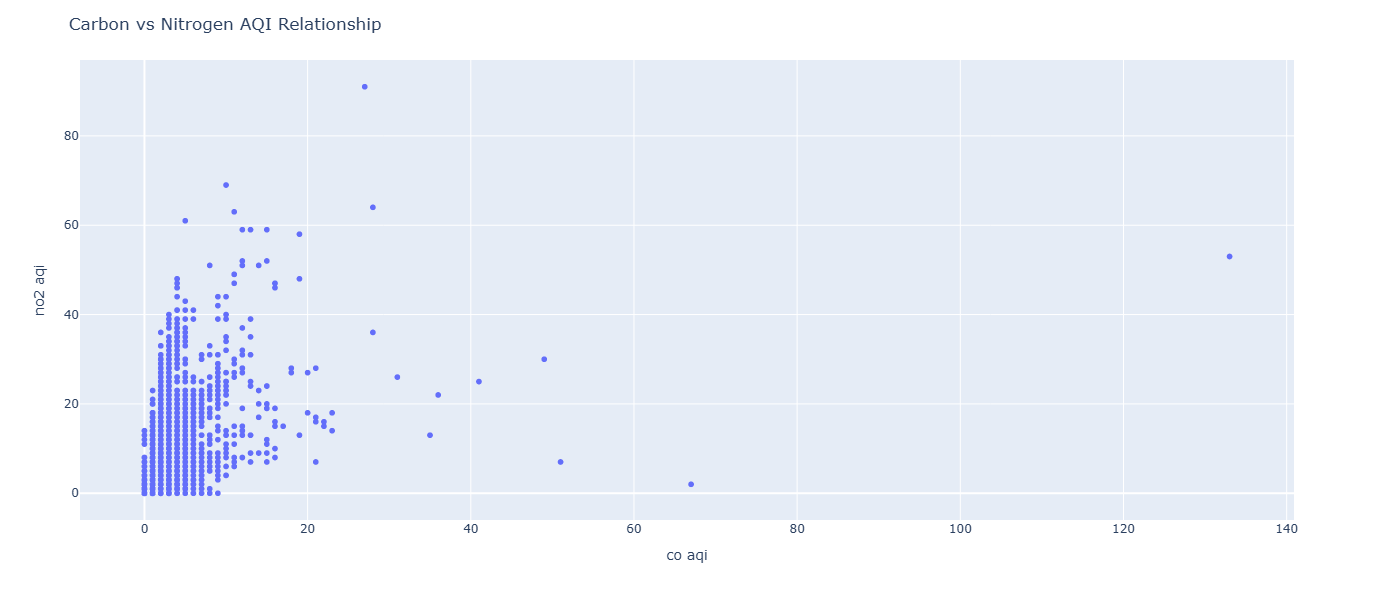

In [117]:
# Using Pyplot
fig = px.scatter(
    df,
    x = 'co_aqi_value\t',
    y = 'no2_aqi_value',
    # marker = 'x',
    labels= {'co_aqi_value\t': 'co aqi', 'no2_aqi_value': 'no2 aqi'},
    hover_data= {'co_aqi_value\t', 'no2_aqi_value'}
)

fig.update_layout(
    height = 600,
    width = 1200,
    title = 'Carbon vs Nitrogen AQI Relationship'
)


fig.show()

## Q18: Scatter plot showing:

### PM2.5 AQI vs Overall AQI

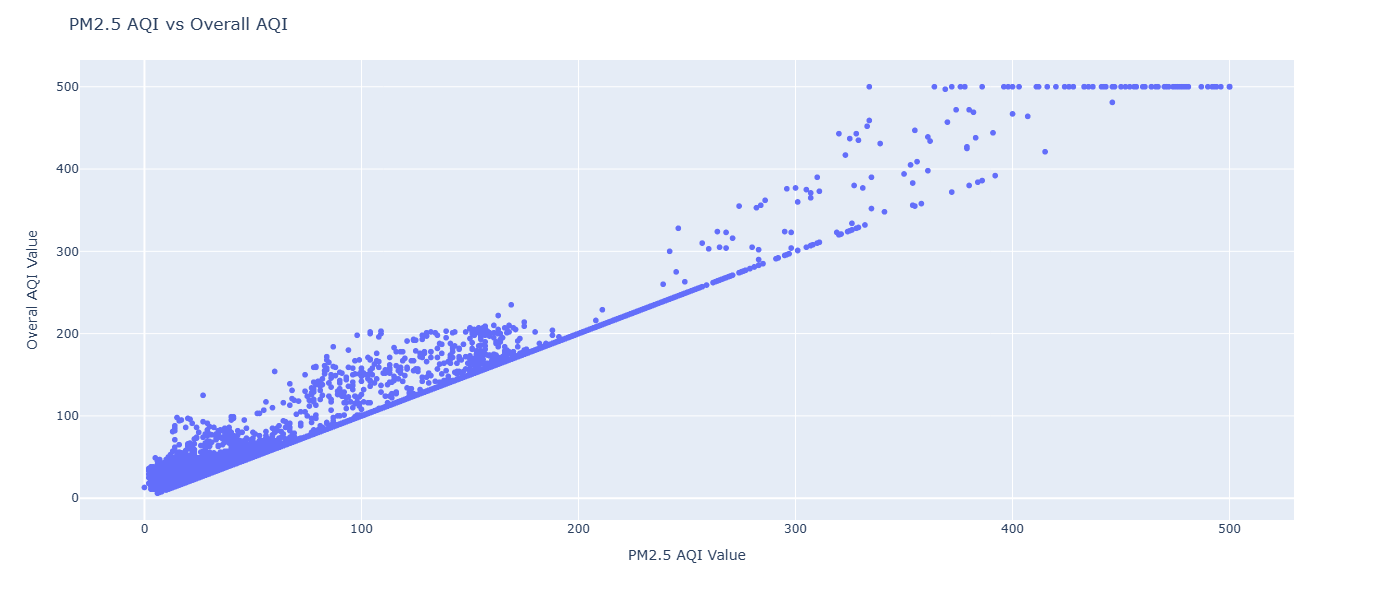

In [118]:
# PM2.5 AQI vs Overall AQI
fig = px.scatter(
    df,
    x = 'pm2.5_aqi_value',
    y = 'aqi_value',
    labels= {'pm2.5_aqi_value': 'PM2.5 AQI Value', 'aqi_value': 'Overal AQI Value'},
    hover_data = {'pm2.5_aqi_value', 'aqi_value'},
)

fig.update_layout(
    height = 600,
    width = 1200,
    title = 'PM2.5 AQI vs Overall AQI'
    
)

fig.show()

## Q19: Box plot comparing:

### PM2.5 AQI distribution across countries

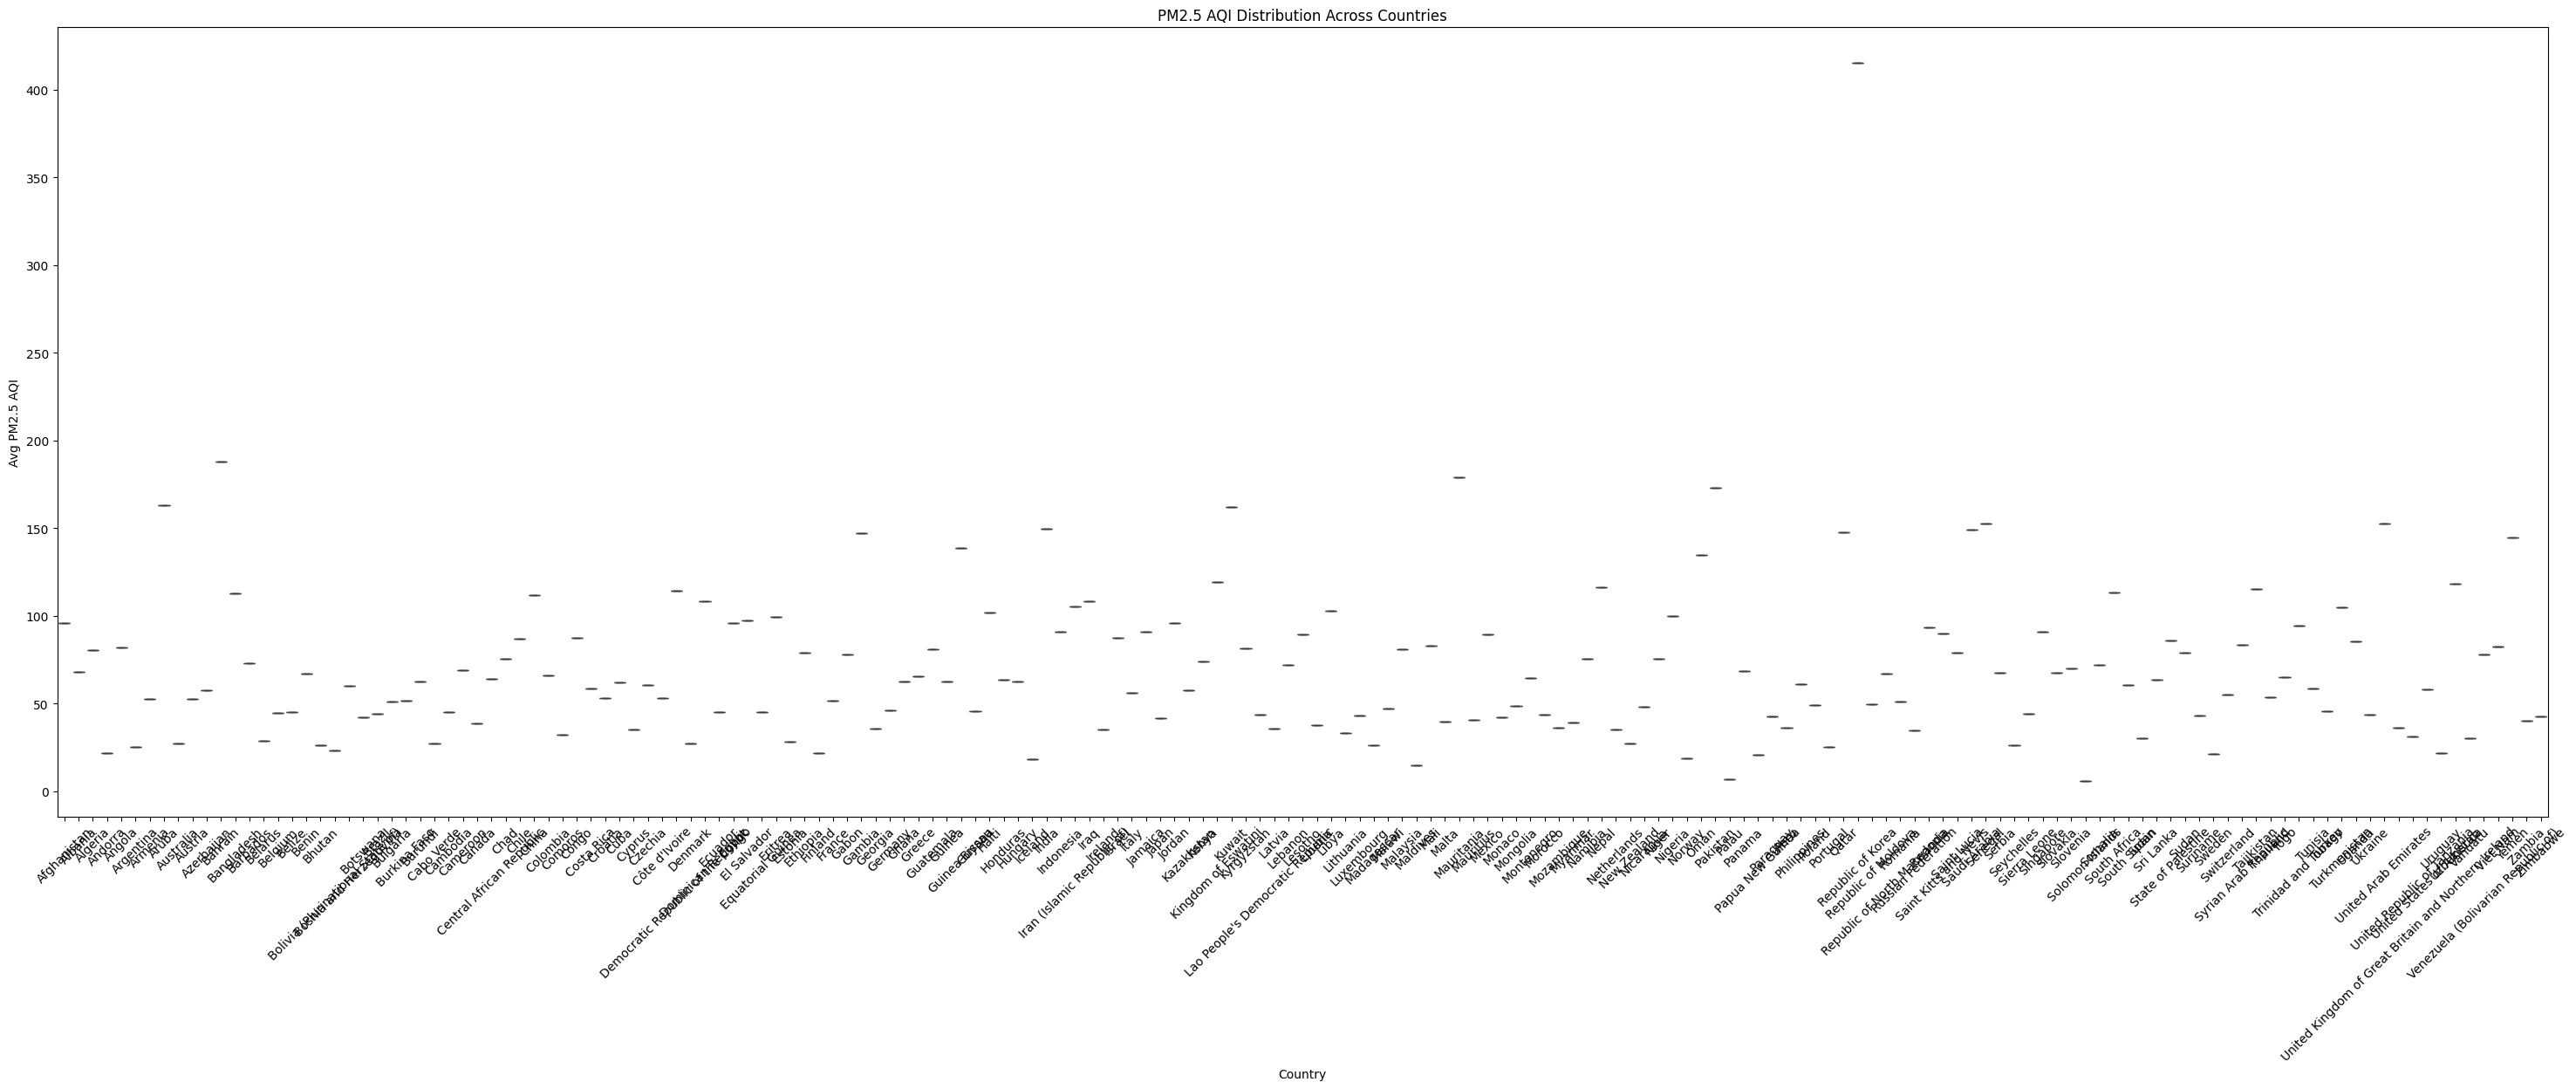

In [119]:
# Usig Seaborn
pm2_aqi_country = df.groupby('country_name')['pm2.5_aqi_value'].mean().reset_index(name = 'avg_pm2.5_aqi_value')

plt.figure(figsize=(30,10))
sns.boxplot(
    pm2_aqi_country,
    x = 'country_name',
    y = 'avg_pm2.5_aqi_value',
    )
plt.xlabel('Country')
plt.ylabel('Avg PM2.5 AQI')
plt.title('PM2.5 AQI Distribution Across Countries')
plt.tight_layout()
plt.xticks(rotation = 45)
plt.show()

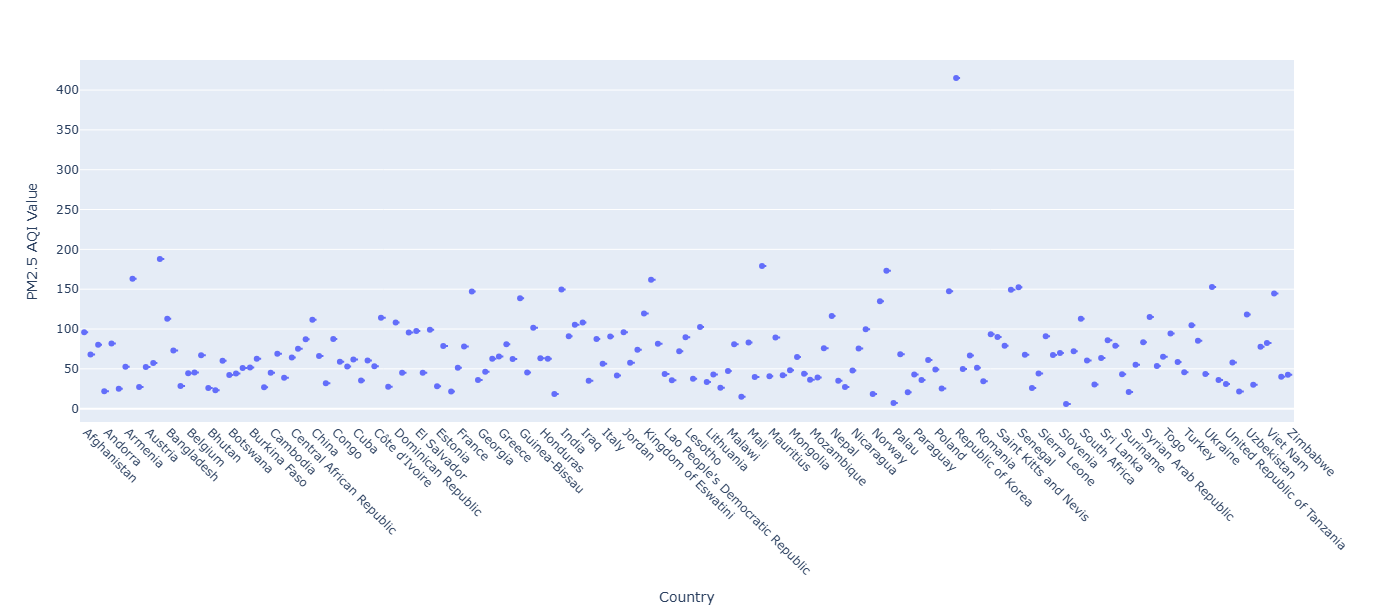

In [120]:
# Using Pyplot
fig = px.box(
    pm2_aqi_country,
    x = 'country_name',
    y = 'avg_pm2.5_aqi_value',
    labels={'country_name': 'Country', 'avg_pm2.5_aqi_value': 'PM2.5 AQI Value'},
    hover_data = {'country_name', 'avg_pm2.5_aqi_value'},
    points= 'all'
)
fig.update_layout(
    height = 600,
    width = 3500,
    xaxis_tickangle = 45
)

fig.show()

# 🧠 Part 5 — Deeper Data Science Questions

## Q20: Which AQI pollutant (CO, NO2, Ozone, PM2.5) has the strongest relationship with the overall AQI value?

In [121]:
# Find correlations for all the pollutants against the generall aqi value
pollutants = ['co_aqi_value\t', 'ozone_aqi_value', 'no2_aqi_value', 'pm2.5_aqi_value']

correlation = {}
for pollutant in pollutants:
    correlation[pollutant] = df[pollutant].corr(df['aqi_value'])
correlation

{'co_aqi_value\t': np.float64(0.4306016428516077),
 'ozone_aqi_value': np.float64(0.4053097578174098),
 'no2_aqi_value': np.float64(0.23175791460152032),
 'pm2.5_aqi_value': np.float64(0.9843265891583709)}

## Q21: Which country appears most frequently in the “Hazardous” AQI category?

In [122]:
# Filter rows where aqi category is harzadous
hazardous_df = df[df['aqi_category'] == 'Hazardous']

# Determining frequency for each country
hazardous_country = hazardous_df['country_name'].value_counts()
hazardous_country
most_frequent_hazardous_country = hazardous_country.idxmax()
print(f'Most frequent country in the “Hazardous” AQI category: {most_frequent_hazardous_country}')

Most frequent country in the “Hazardous” AQI category: India


## Q22: Which city appears most frequently in the “Unhealthy” AQI category?

In [127]:
unhealthy_df = df[df['aqi_category'] == 'Unhealthy']
unhealthy_city = unhealthy_df['city_name'].value_counts()
unhealthy_city.idxmax() # Since value_counts() sorts in descending by default

'Gursahaiganj'

## Q23: Create a correlation matrix for the numerical AQI variables.

In [133]:
df.select_dtypes(include='number').columns # Selects just the column names
df_numerical_columns = df.select_dtypes(include='number') # Selects both column and values
df_numerical_columns.corr()

,aqi_value,co_aqi_value\t,ozone_aqi_value,no2_aqi_value,pm2.5_aqi_value
aqi_value,1.000000,0.430602,0.405310,0.231758,0.984327
co_aqi_value\t,0.430602,1.000000,0.145724,0.488092,0.438557
ozone_aqi_value,0.405310,0.145724,1.000000,-0.181818,0.339887
no2_aqi_value,0.231758,0.488092,-0.181818,1.000000,0.260127
pm2.5_aqi_value,0.984327,0.438557,0.339887,0.260127,1.000000


C:\Users\chiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning:

Glyph 9 (	) missing from font(s) DejaVu Sans.

C:\Users\chiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 9 (	) missing from font(s) DejaVu Sans.



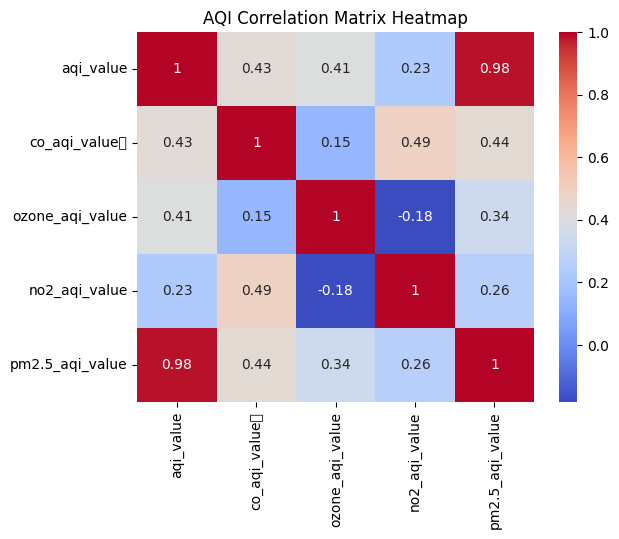

In [144]:
# Visualization using a heat map
sns.heatmap(df_numerical_columns.corr(), annot=True, cmap=  'coolwarm')
plt.title('AQI Correlation Matrix Heatmap')
plt.show()

## Q24: Based on the correlation matrix, determine which pollutant is the best predictor of overall AQI.

In [ ]:
The pollutant most strongly related to the overall AQI is PM2.5.